In [1]:
# ===============================================
# Mobile Phone Price Prediction
# Feature Extraction & Machine Learning Project
# ===============================================

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# -----------------------------------
# Load Dataset
# -----------------------------------

df = pd.read_csv("Processed_Flipdata_Processed_Flipdata.csv")

In [5]:
df.shape

(541, 12)

In [6]:
# -----------------------------------
# Data Exploration
# -----------------------------------

In [7]:
print("\nData Information")
df.info()


Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [8]:
print("\nMissing value check")
df.isnull().sum()


Missing value check


Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [9]:
print("\nStatistics")
print(df.describe(include="all"))


Statistics
        Unnamed: 0     Model  Colour      Memory         RAM     Battery_  \
count   541.000000       541     541  541.000000  541.000000   541.000000   
unique         NaN       187     275         NaN         NaN          NaN   
top            NaN  vivo Y16  Yellow         NaN         NaN          NaN   
freq           NaN         9      12         NaN         NaN          NaN   
mean    289.711645       NaN     NaN  110.550832    5.397412  4871.587800   
std     182.359185       NaN     NaN   60.600694    1.984923   780.148862   
min       0.000000       NaN     NaN   16.000000    2.000000   800.000000   
25%     135.000000       NaN     NaN   64.000000    4.000000  5000.000000   
50%     273.000000       NaN     NaN  128.000000    6.000000  5000.000000   
75%     434.000000       NaN     NaN  128.000000    8.000000  5000.000000   
max     642.000000       NaN     NaN  256.000000    8.000000  7000.000000   

       Rear Camera Front Camera     AI Lens  Mobile Height  \
c

In [10]:
# -----------------------------------
# Data Cleaning
# -----------------------------------

In [11]:
# Remove unwanted column
df.drop(columns=["Unnamed: 0"], inplace=True)

In [12]:
df

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
...,...,...,...,...,...,...,...,...,...,...,...
536,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"


In [13]:
# Remove commas from price and convert to integer
df["Prize"] = (df["Prize"].str.replace(",", "", regex=False).astype(int))

In [14]:
df

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
...,...,...,...,...,...,...,...,...,...,...,...
536,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999


In [15]:
# Fill missing values using for loop
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [16]:
# -----------------------------------
# Correlation
# -----------------------------------

contVar = df.columns[df.dtypes != "object"]

print('\n contVar print')
contVar


 contVar print


Index(['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Prize'], dtype='object')

<AxesSubplot: >

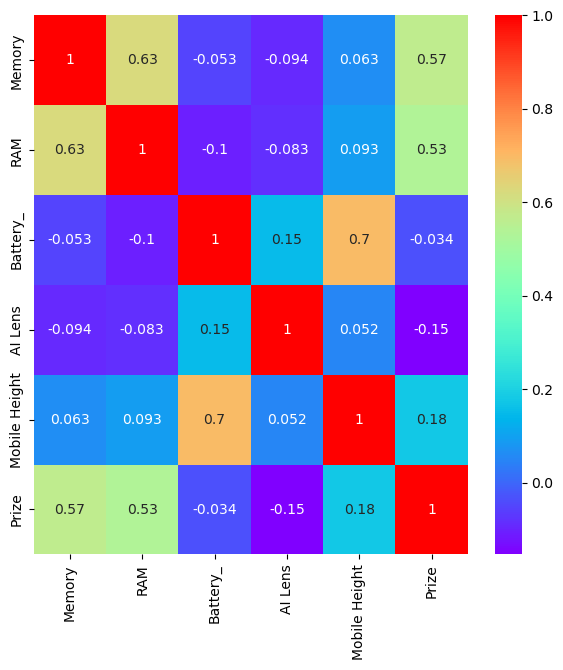

In [17]:
corrDf = df[contVar].corr()
plt.figure(figsize=(7,7))
sns.heatmap(corrDf,annot=True,cmap='rainbow')

In [18]:
# -----------------------------------
# Encode Categorical Features
# -----------------------------------

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])
        
df

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,23,159,64,4,6000,3,10,1,16.76,113,7299
1,23,20,64,4,6000,3,10,1,16.76,113,7299
2,37,149,128,8,5000,10,4,0,16.64,75,11999
3,69,201,32,2,5000,13,10,0,16.56,56,5649
4,12,130,128,8,5000,10,10,1,16.76,14,8999
...,...,...,...,...,...,...,...,...,...,...,...
536,118,49,256,8,3900,10,2,0,15.49,89,79999
537,32,52,32,2,3100,11,6,0,12.70,68,5998
538,123,259,64,4,5000,10,12,0,16.76,35,9990
539,110,17,128,8,5000,10,7,0,16.26,11,38999


<AxesSubplot: title={'center': 'Correlation Matrix'}>

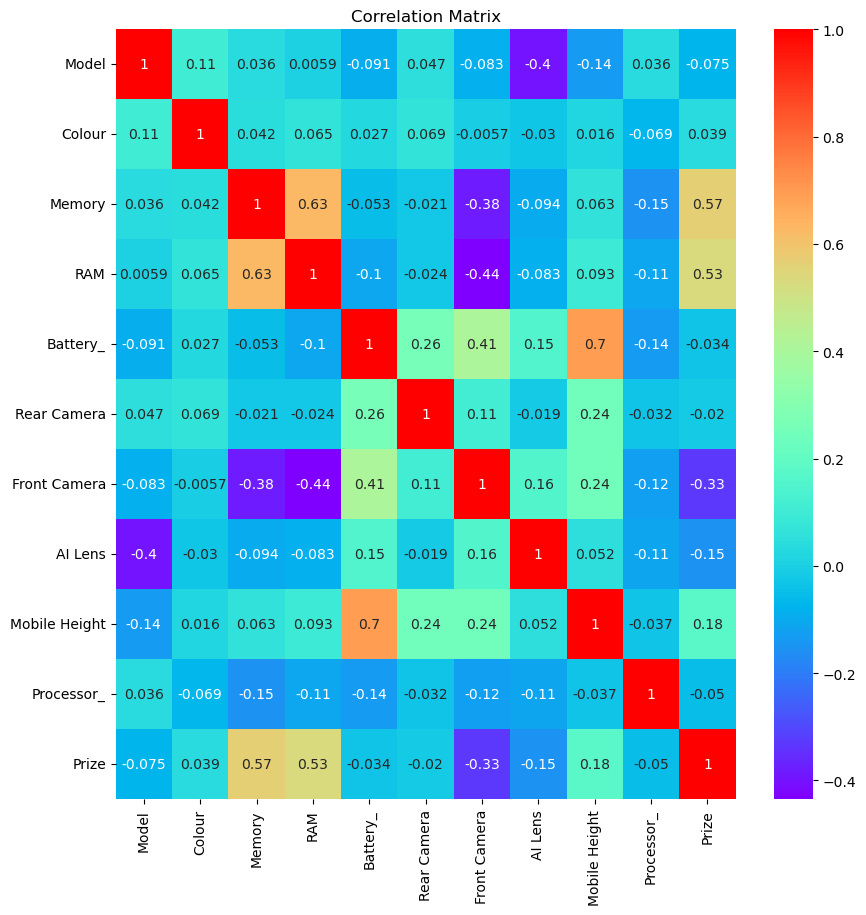

In [19]:
# -----------------------------------
# Correlation
# -----------------------------------
corrDf1 = df.corr()
plt.figure(figsize=(10,10))
plt.title("Correlation Matrix")
sns.heatmap(corrDf1,annot=True,cmap='rainbow')

In [20]:
# -----------------------------------
# Split Dataset
# -----------------------------------

X = df.drop("Prize", axis=1)
y = df["Prize"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n========== Linear Regression ==========")

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 :", r2_score(y_test, lr_pred))


========== Linear Regression ==========
MAE : 4601.918779350485
RMSE : 9676.327022495989
R2 : 0.32066456326017123


In [22]:
# -----------------------------------
# Random Forest
# -----------------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 :", r2_score(y_test, rf_pred))


========== Random Forest ==========
MAE : 1856.29499017038
RMSE : 5441.54900920935
R2 : 0.7851633929868275


In [23]:
# -----------------------------------
# Feature Importance
# -----------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)


Feature Importance
         Feature  Importance
0          Model    0.298622
2         Memory    0.265643
6   Front Camera    0.112685
4       Battery_    0.096226
8  Mobile Height    0.073545
3            RAM    0.071430
9     Processor_    0.048736
1         Colour    0.020613
5    Rear Camera    0.012295
7        AI Lens    0.000203


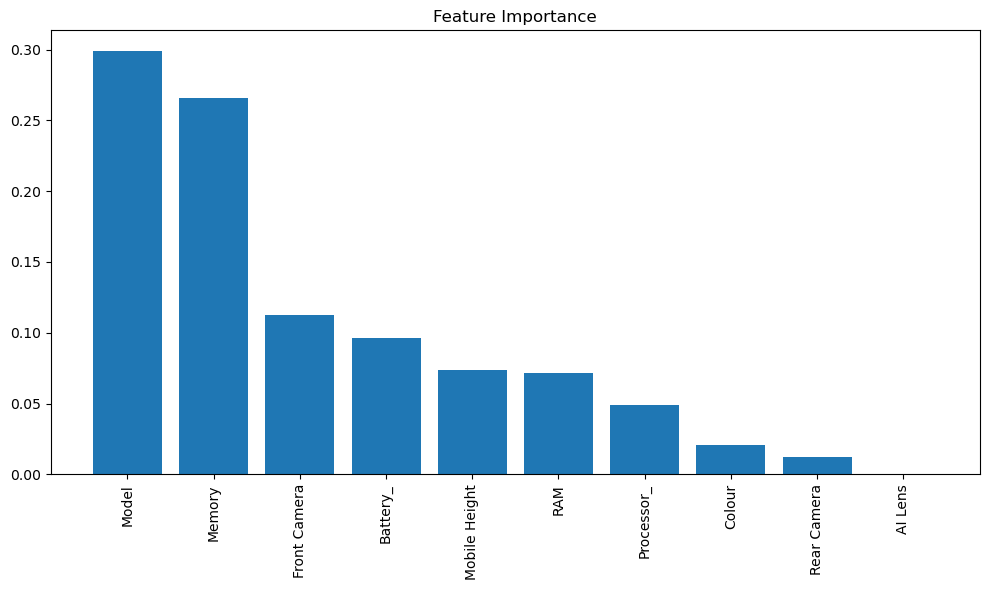

In [24]:
# Plot

plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()


    Actual  Predicted
0     8499       8730
1     6299       6564
2    19499      19295
3    10999      11184
4    12599      12886
5    14499      14639
6     9999       9994
7    17999      16965
8    29499      28527
9     9790      10697
10    8999       9335
11   29999      34450
12   19499      19295
13   16499      16823
14   32999      32649
15   16999      16336
16    9999       9907
17   15999      17589
18   23999      24054
19   18999      20377


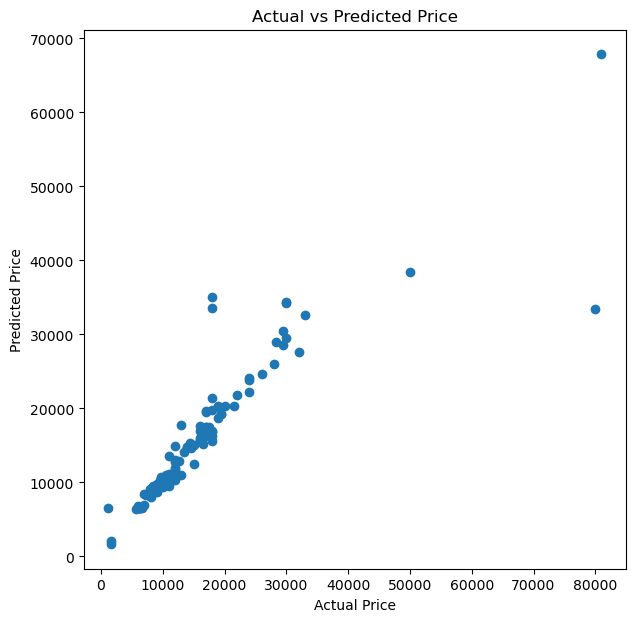

In [25]:
# -----------------------------------
# Actual vs Predicted
# -----------------------------------

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred.astype(int)
})

print(result.head(20))

plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

In [28]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [30]:
dt_pred = dt.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Decision Tree Results")
print("---------------------")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Results
---------------------
MAE : 2402.87796278169
RMSE : 6582.595716539855
R2 Score : 0.6856180810617872


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
0          Model    0.327884
2         Memory    0.309099
6   Front Camera    0.182161
8  Mobile Height    0.085990
4       Battery_    0.043154
9     Processor_    0.022523
1         Colour    0.013826
3            RAM    0.010847
5    Rear Camera    0.004165
7        AI Lens    0.000350


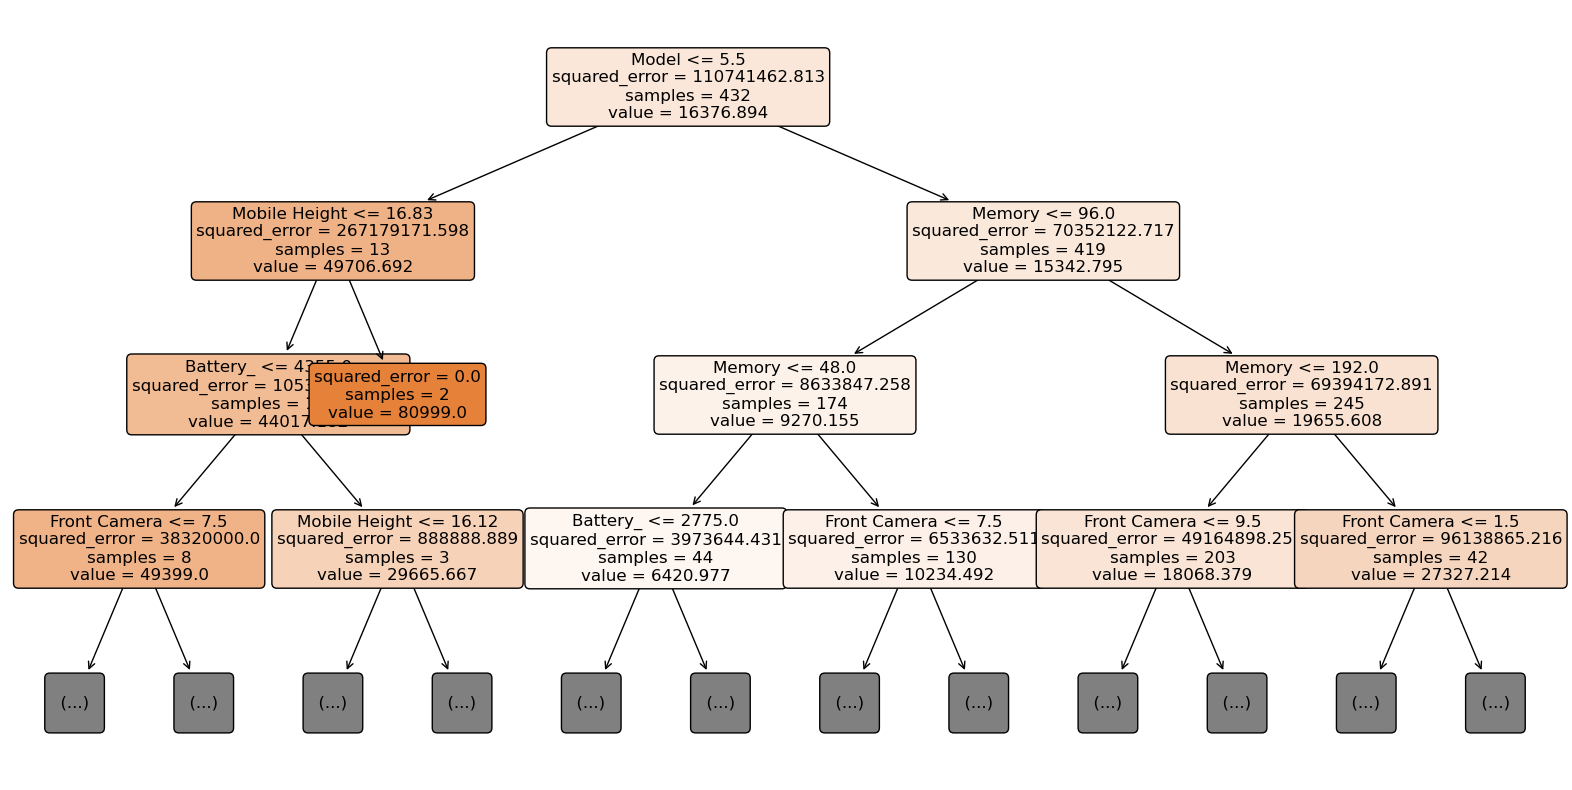

In [42]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,   # Show only the first 3 levels for readability
    fontsize=12
)

plt.show()